In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, MaxPooling1D, Flatten,
                                     Dense, Dropout, Concatenate)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
# load & print data
data_path = os.path.join("data", "exp_pro", "stroke_patients.csv")
df = pd.read_csv(data_path)

print("Initial rows:", len(df))
print(df.head(), "\n")
print("Columns:", df.columns.tolist(), "\n")

Initial rows: 167
  cohort_start_date  race_concept_id  gender_concept_id  age  AHRSWORKT  \
0        2010-01-06             8527               8507   27  38.429379   
1        2010-01-10             8527               8532   28  38.643979   
2        2010-01-12             8527               8507   25  36.526316   
3        2010-01-13             8527               8532   21  30.125984   
4        2010-01-13             8527               8532   27  38.429379   

     HEALTH  Temperature  stroke  
0  1.870056         22.1       1  
1  1.858639         22.1       1  
2  1.725146         22.1       1  
3  1.826772         22.1       1  
4  1.870056         22.1       1   

Columns: ['cohort_start_date', 'race_concept_id', 'gender_concept_id', 'age', 'AHRSWORKT', 'HEALTH', 'Temperature', 'stroke'] 



In [5]:
# define colums
weather_cols = ['Temperature']
tabular_cols = [
    'cohort_start_date',
    'race_concept_id',
    'gender_concept_id',
    'age',
    'AHRSWORKT',
    'HEALTH'
]
target_col = 'stroke'

In [6]:
# cleaning and drop nan
# drop rows with missing target
df = df.dropna(subset=[target_col])

# drop rows with missing weather or tabular features
df = df.dropna(subset=weather_cols + tabular_cols)

print("After dropping missing, rows:", len(df))

After dropping missing, rows: 161


In [7]:
# make data numerical
# convert cohort_start_date to year/month/day/dow
df['cohort_start_date'] = pd.to_datetime(df['cohort_start_date'], errors='coerce')
df['start_year']  = df['cohort_start_date'].dt.year
df['start_month'] = df['cohort_start_date'].dt.month
df['start_day']   = df['cohort_start_date'].dt.day
df['start_dow']   = df['cohort_start_date'].dt.dayofweek
df = df.drop(columns=['cohort_start_date'])

# add the new date columns to tabular_cols, drop the original
tabular_cols = [
    'race_concept_id',
    'gender_concept_id',
    'age',
    'AHRSWORKT',
    'HEALTH',
    'start_year',
    'start_month',
    'start_day',
    'start_dow'
]

In [8]:
# extract
# target
y = df[target_col].astype(int).to_numpy()

# weather → (n, 1, 1)
weather_arr  = df[weather_cols].to_numpy()              # shape (n, 1)
weather_data = weather_arr[..., np.newaxis]            # shape (n, 1, 1)

# tabular → (n, f)
X_tabular_df = df[tabular_cols].copy()
X_tabular    = X_tabular_df.to_numpy()

print("Shapes:", 
      "weather_data:", weather_data.shape,
      "X_tabular:",   X_tabular.shape,
      "y:",           y.shape)

# must all match in the first dimension
assert weather_data.shape[0] == X_tabular.shape[0] == y.shape[0]

Shapes: weather_data: (161, 1, 1) X_tabular: (161, 9) y: (161,)


In [9]:
# train test split
X_w_train, X_w_test, X_t_train, X_t_test, y_train, y_test = train_test_split(
    weather_data, X_tabular, y, test_size=0.2, random_state=42
)

In [10]:
# scale tubular
scaler = StandardScaler()
X_t_train = scaler.fit_transform(X_t_train)
X_t_test  = scaler.transform(X_t_test)

In [11]:
# build model 
# dynamic kernel/pool to handle time_steps=1
time_steps          = X_w_train.shape[1]   # likely 1
weather_feature_dim = X_w_train.shape[2]   # likely 1
kernel_size = min(3, time_steps)
pool_size   = min(2, time_steps)

In [12]:
# weather branch
weather_input = Input(shape=(time_steps, weather_feature_dim), name='weather_input')
x = Conv1D(32, kernel_size=kernel_size, activation='relu')(weather_input)
x = MaxPooling1D(pool_size=pool_size)(x)
x = Conv1D(64, kernel_size=kernel_size, activation='relu')(x)
x = MaxPooling1D(pool_size=pool_size)(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
weather_branch = Dropout(0.5)(x)

In [13]:
# tabular branch
tabular_input = Input(shape=(X_t_train.shape[1],), name='tabular_input')
yb = Dense(64, activation='relu')(tabular_input)
yb = Dropout(0.5)(yb)
yb = Dense(64, activation='relu')(yb)
yb = Dense(128, activation='relu')(yb)

In [14]:
# fusion
merged = Concatenate()([weather_branch, yb])
z = Dense(64, activation='relu')(merged)
z = Dropout(0.5)(z)
z = Dense(32, activation='relu')(z)
output = Dense(1, activation='sigmoid', name='output')(z)

In [15]:
model = Model(inputs=[weather_input, tabular_input], outputs=output)
model.compile(optimizer=Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ weather_input       │ (None, 1, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1, 32)     │         64 │ weather_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 1, 32)     │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 1, 64)     │      2,112 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_input       │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 1, 64)     │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        640 │ tabular_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 64)        │          0 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      8,320 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      4,160 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │      8,320 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │     16,448 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 42,177 (164.75 KB)

 Trainable params: 42,177 (164.75 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# training 
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(
    [X_w_train, X_t_train], y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    callbacks=[early_stop]
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3878 - loss: 2.4419 - val_accuracy: 1.0000 - val_loss: 0.5726
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4398 - loss: 1.8821 - val_accuracy: 1.0000 - val_loss: 0.3183
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5338 - loss: 1.3095 - val_accuracy: 1.0000 - val_loss: 0.2007
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6194 - loss: 1.1077 - val_accuracy: 1.0000 - val_loss: 0.1325
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7099 - loss: 0.5962 - val_accuracy: 1.0000 - val_loss: 0.1004
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8181 - loss: 0.4882 - val_accuracy: 1.0000 - val_loss: 0.0792
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7634 - loss: 0.5944 - val_accuracy: 1.0000 - val_loss: 0.0629
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7691 - loss: 0.5230 - val_accuracy: 1.0000 - val_loss: 0.0502
Epoch 9

In [17]:
# eval
test_loss, test_acc = model.evaluate([X_w_test, X_t_test], y_test)
print(f"\nTest loss: {test_loss:.4f}, Test accuracy: {test_acc:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0020

Test loss: 0.0020, Test accuracy: 1.0000


Text(0.5, 1.0, 'Accuracy')

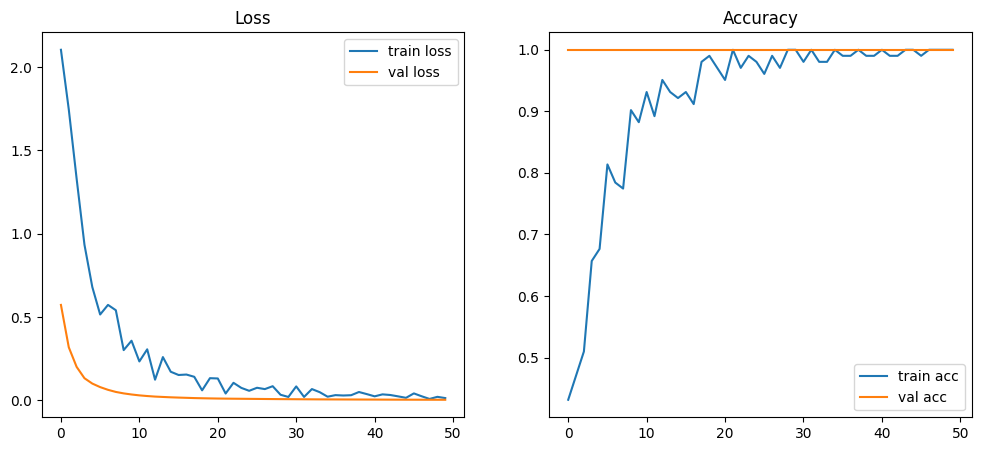

In [20]:
# plot 
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title('Accuracy')